1. Naive Bayes

--- Gaussian Naive Bayes Results ---
Accuracy: 0.8300

Classification Report:
              precision    recall  f1-score   support

        High       0.91      0.74      0.82        78
         Low       0.93      0.93      0.93        60
      Medium       0.68      0.84      0.75        62

    accuracy                           0.83       200
   macro avg       0.84      0.84      0.83       200
weighted avg       0.85      0.83      0.83       200



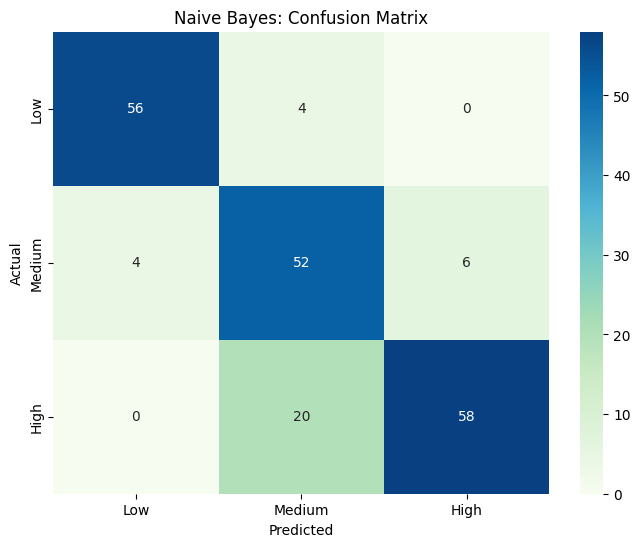

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
data_nb = pd.read_csv('sports_training_dataset.csv')
low_t = data_nb['training_effectiveness'].quantile(0.33)
high_t = data_nb['training_effectiveness'].quantile(0.66)
def categorize_nb(val):
    if val <= low_t: return 'Low'
    elif val <= high_t: return 'Medium'
    else: return 'High'
data_nb['target_class'] = data_nb['training_effectiveness'].apply(categorize_nb)
nb_features = data_nb.select_dtypes(include=[np.number]).columns.tolist()
if 'training_effectiveness' in nb_features:
    nb_features.remove('training_effectiveness')
X = data_nb[nb_features]
y = data_nb['target_class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
y_pred = nb_model.predict(X_test)
print(f"--- Gaussian Naive Bayes Results ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
plt.figure(figsize=(8, 6))
cm_nb = confusion_matrix(y_test, y_pred, labels=['Low', 'Medium', 'High'])
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='GnBu',
            xticklabels=['Low', 'Medium', 'High'],
            yticklabels=['Low', 'Medium', 'High'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Naive Bayes: Confusion Matrix')
plt.show()

2. KNN

Best K value found: 18 with Accuracy: 0.6350

--- KNN Classification Results (K=18) ---
Accuracy: 0.6350

Classification Report:
              precision    recall  f1-score   support

        High       0.74      0.67      0.70        78
         Low       0.70      0.72      0.71        60
      Medium       0.46      0.52      0.49        62

    accuracy                           0.64       200
   macro avg       0.64      0.63      0.63       200
weighted avg       0.64      0.64      0.64       200



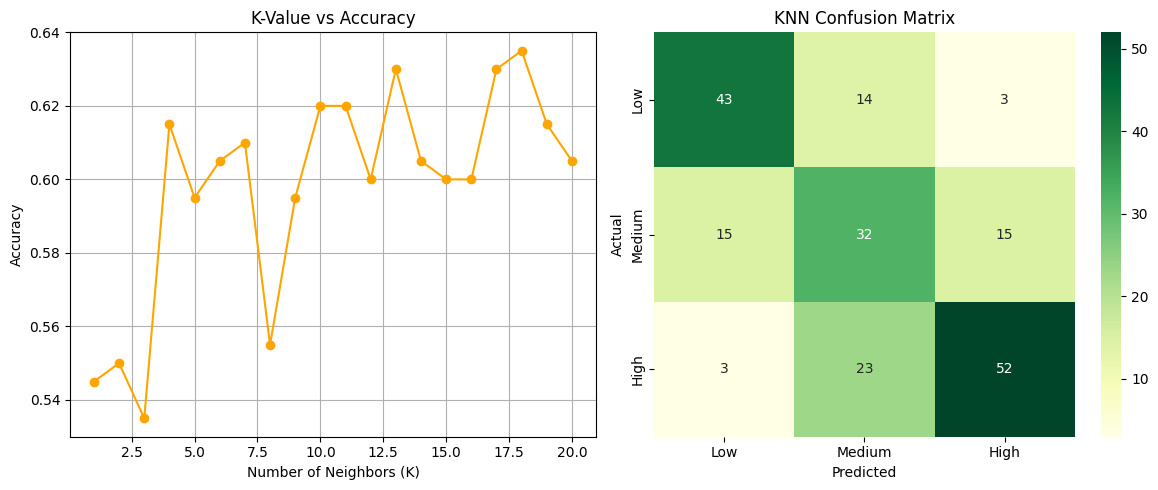

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
data_knn = pd.read_csv('sports_training_dataset.csv')
low_t = data_knn['training_effectiveness'].quantile(0.33)
high_t = data_knn['training_effectiveness'].quantile(0.66)
def categorize_knn(val):
    if val <= low_t: return 'Low'
    elif val <= high_t: return 'Medium'
    else: return 'High'
data_knn['target_class'] = data_knn['training_effectiveness'].apply(categorize_knn)
knn_features = data_knn.select_dtypes(include=[np.number]).columns.tolist()
if 'training_effectiveness' in knn_features:
    knn_features.remove('training_effectiveness')
X = data_knn[knn_features]
y = data_knn['target_class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
scores = []
for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred_k = knn.predict(X_test_scaled)
    scores.append(accuracy_score(y_test, y_pred_k))
best_k = np.argmax(scores) + 1
print(f"Best K value found: {best_k} with Accuracy: {max(scores):.4f}")
knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train_scaled, y_train)
y_pred = knn_model.predict(X_test_scaled)
print(f"\n--- KNN Classification Results (K={best_k}) ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, 21), scores, marker='o', color='orange')
plt.title('K-Value vs Accuracy')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Accuracy')
plt.grid(True)
plt.subplot(1, 2, 2)
cm_knn = confusion_matrix(y_test, y_pred, labels=['Low', 'Medium', 'High'])
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='YlGn',
            xticklabels=['Low', 'Medium', 'High'],
            yticklabels=['Low', 'Medium', 'High'])
plt.title('KNN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

BEST MODEL: MULTI LINEAR REGRESSION

Original X shape: (1000, 25)
Original y shape: (1000,)
X shape after selecting numerical features: (1000, 24)


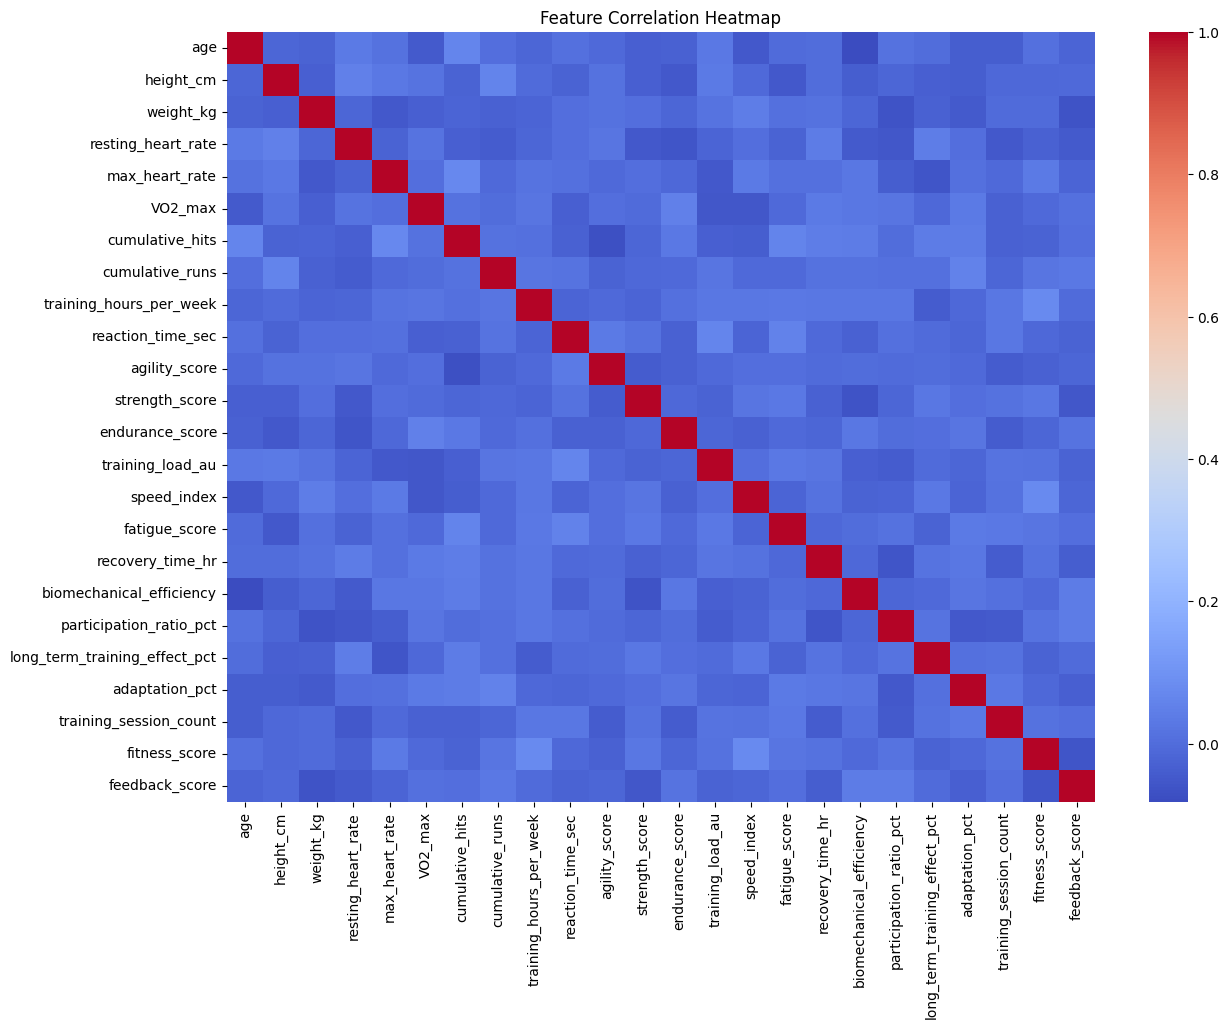


Low Variance Features:
Index([], dtype='object')
Shape After Dimensionality Reduction (low variance features removed):
(1000, 24)
age : Removed 0 outliers
height_cm : Removed 0 outliers
weight_kg : Removed 0 outliers
resting_heart_rate : Removed 0 outliers
max_heart_rate : Removed 0 outliers
VO2_max : Removed 0 outliers
cumulative_hits : Removed 0 outliers
cumulative_runs : Removed 0 outliers
training_hours_per_week : Removed 0 outliers
reaction_time_sec : Removed 0 outliers
agility_score : Removed 0 outliers
strength_score : Removed 0 outliers
endurance_score : Removed 0 outliers
training_load_au : Removed 0 outliers
speed_index : Removed 0 outliers
fatigue_score : Removed 0 outliers
recovery_time_hr : Removed 0 outliers
biomechanical_efficiency : Removed 0 outliers
participation_ratio_pct : Removed 0 outliers
long_term_training_effect_pct : Removed 0 outliers
adaptation_pct : Removed 0 outliers
training_session_count : Removed 0 outliers
fitness_score : Removed 0 outliers
feedback_s

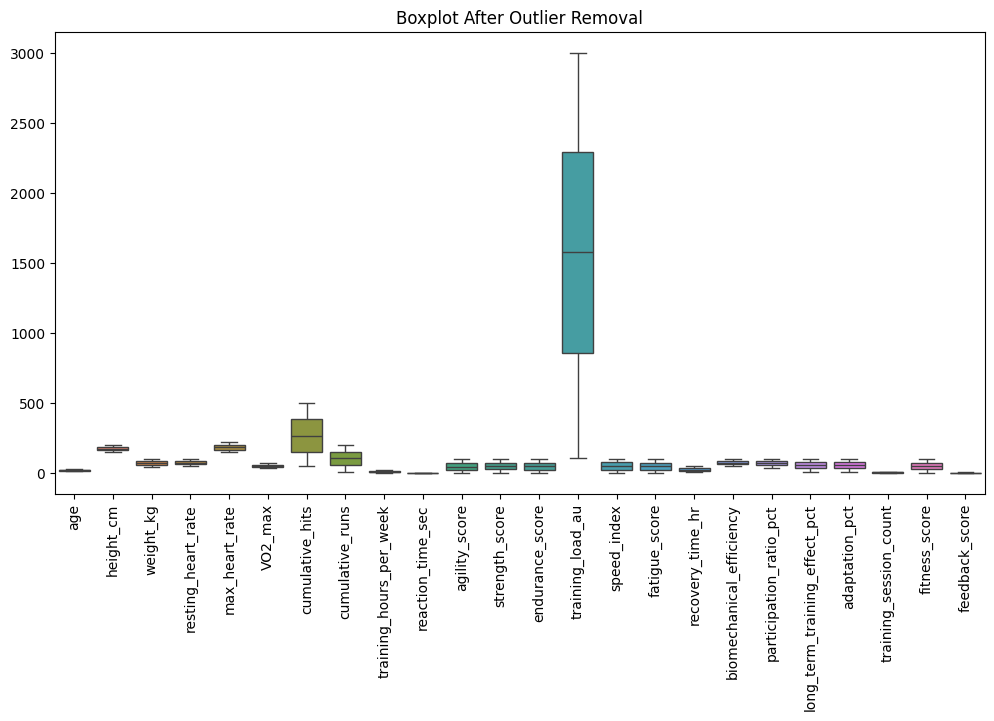


--- Multi-Linear Regression Results ---
R-squared Score: 1.0000
Mean Squared Error: 0.0000


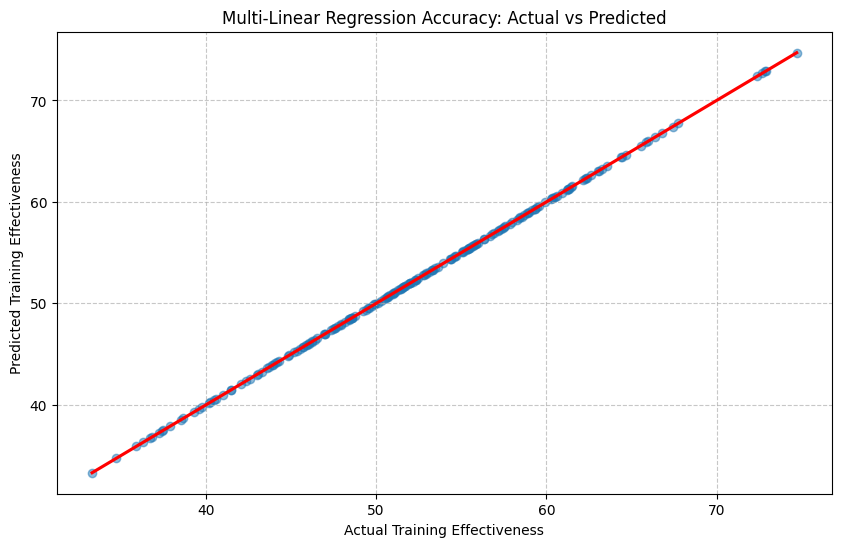

In [6]:
import json
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
data = pd.read_csv('sports_training_dataset.csv')
target_column = 'training_effectiveness'
y = data[target_column]
X = data.drop(target_column, axis=1)
print("Original X shape:", X.shape)
print("Original y shape:", y.shape)
numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()
X = X[numerical_cols]
print("X shape after selecting numerical features:", X.shape)
plt.figure(figsize=(14,10))
sns.heatmap(X.corr(), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()
variance = X.var()
low_variance_features = variance[variance < 0.01].index
print("\nLow Variance Features:")
print(low_variance_features)
X = X.drop(columns=low_variance_features, axis=1)
print("Shape After Dimensionality Reduction (low variance features removed):")
print(X.shape)
for col in X.columns:
    mean = X[col].mean()
    std = X[col].std()
    upper_limit = mean + (3 * std)
    lower_limit = mean - (3 * std)
    before_shape = X.shape[0]
    mask = (X[col] >= lower_limit) & (X[col] <= upper_limit)
    X = X[mask]
    y = y[mask]
    after_shape = X.shape[0]
    print(f"{col} : Removed {before_shape - after_shape} outliers")
print("Final Shape After Outlier Removal:")
print(X.shape)
plt.figure(figsize=(12,6))
sns.boxplot(data=X)
plt.xticks(rotation=90)
plt.title("Boxplot After Outlier Removal")
plt.show()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
model = LinearRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"\n--- Multi-Linear Regression Results ---")
print(f"R-squared Score: {r2:.4f}")
print(f"Mean Squared Error: {mse:.4f}")
plt.figure(figsize=(10, 6))
sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.xlabel('Actual Training Effectiveness')
plt.ylabel('Predicted Training Effectiveness')
plt.title('Multi-Linear Regression Accuracy: Actual vs Predicted')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [7]:
with open("linear_regression_model.pkl", "wb") as file:
    pickle.dump(model, file)
with open("scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)
columns_data = {"data_columns": [col.lower() for col in X.columns]}
with open("columns.json", "w") as file:
    json.dump(columns_data, file, indent=4)